# Experiment: Aggregate candidate-base and implementation frontier

**Objective.** Decide which already-frozen result is the most defensible base for
future testing once gross signal, 10-bps economics, concentration, inference,
capacity, and evidence provenance are considered together.

This is an **aggregate-only decision audit**. It loads no price, return-path,
position, score, headline, or licensed-text row; constructs no signal or return;
and performs no parameter search. FNSPID and each LSEG regime remain non-pooled.

A useful outcome is a role-separated base stack—not a retrospective Sharpe winner:
research benchmark, prospective primary, non-promoting risk diagnostic, and
historical comparator. A validated-alpha claim is impossible on these opened data.


In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import ListedColormap

SEED = 20260821
np.random.seed(SEED)
ROOT = Path.cwd()
if ROOT.name == "final_experiments":
    ROOT = ROOT.parent
assert (ROOT / "final_experiments").exists(), ROOT
OUTPUT = ROOT / "final_experiments/outputs/57_aggregate_candidate_base_frontier"
OUTPUT.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")


def sha256(path: str | Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def read_json(path: str | Path) -> dict:
    return json.loads(Path(path).read_text())


def one(frame: pd.DataFrame, **filters: object) -> pd.Series:
    mask = pd.Series(True, index=frame.index)
    for column, value in filters.items():
        mask &= frame[column].eq(value)
    selected = frame.loc[mask]
    assert len(selected) == 1, (filters, len(selected))
    return selected.iloc[0]


def git_commit() -> str:
    return subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()


CSV_PATHS = {
    "n21_results": "final_experiments/outputs/21_fnspid_sentiment_volatility_target/strategy_results.csv",
    "n33_results": "final_experiments/outputs/33_lseg_gemma_original33_universe_robustness/results.csv",
    "n33_gates": "final_experiments/outputs/33_lseg_gemma_original33_universe_robustness/gates.csv",
    "n35_gates": "final_experiments/outputs/35_lseg_gemma_event_timing_circular_shift/gates.csv",
    "n36_result": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/hybrid_result.csv",
    "n36_gates": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/gates.csv",
    "n36_cost_curve": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/cost_curve.csv",
    "n46_results": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/strategy_results.csv",
    "n46_gates": "final_experiments/outputs/46_lseg_external_time_har_base_transfer/gates.csv",
    "n48_results": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/results.csv",
    "n48_gates": "final_experiments/outputs/48_lseg_gemma_persistent_revision_state/gates.csv",
    "n50_results": "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/results.csv",
    "n50_gates": "final_experiments/outputs/50_lseg_gemma_hybrid_inverse_volatility/gates.csv",
    "n51_curve": "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/capacity_curve.csv",
    "n51_gates": "final_experiments/outputs/51_lseg_gemma_hybrid_implementation_capacity/gates.csv",
    "n54_summary": "final_experiments/outputs/54_lseg_prospective_batch_ledger/population_summary.csv",
    "n54_gates": "final_experiments/outputs/54_lseg_prospective_batch_ledger/population_gate.csv",
    "n55_periods": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/period_results.csv",
    "n55_gates": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/gates.csv",
    "n55_inference": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/evaluation_inference.csv",
    "n55_concentration": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/concentration_summary.csv",
}
JSON_PATHS = {
    "n36_manifest": "final_experiments/outputs/36_lseg_gemma_finbert_hybrid_alpha_audit/manifest.json",
    "n54_manifest": "final_experiments/outputs/54_lseg_prospective_batch_ledger/manifest.json",
    "n55_manifest": "final_experiments/outputs/55_lseg_midcap_finbert_baseline_reconciliation/manifest.json",
    "n56_manifest": "final_experiments/outputs/56_local_lseg_finbert_strategy_lineage/manifest.json",
    "prospective_spec": "final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_prospective_v1.json",
}
assert all(Path(path).suffix in {".csv", ".json"} for path in [*CSV_PATHS.values(), *JSON_PATHS.values()])
len(CSV_PATHS) + len(JSON_PATHS)


26

## Plan

1. Reproduce the existing aggregate metrics and identity links; fail if the
   Notebook 36 equal-weight hybrid differs from Notebook 50's control.
2. Compare candidate roles on reported gross/net Sharpe, 10-bps break-even,
   turnover, drawdown, active sessions, and maximum name weight. Values from
   different regimes are displayed but never pooled or formally ranked.
3. Audit the frozen primary on cash, timing, both-halves, factor, dependence,
   fixed-cost, and impact-capacity gates. Missing non-comparable gates stay grey.
4. Preserve the source-controlled prospective choice. Notebook 57 may confirm
   that choice or expose a contradiction; it may not replace it from outcomes.
5. Stop with no new return if the prospective population is below 120 sessions.


In [2]:
tables = {name: pd.read_csv(ROOT / path) for name, path in CSV_PATHS.items()}
documents = {name: read_json(ROOT / path) for name, path in JSON_PATHS.items()}
source_files = pd.DataFrame(
    [
        {"source": name, "path": path, "sha256": sha256(ROOT / path)}
        for name, path in {**CSV_PATHS, **JSON_PATHS}.items()
    ]
)
source_files.to_csv(OUTPUT / "source_files.csv", index=False)

n21_har = one(tables["n21_results"], arm="control_har_target")
n33_capped = one(tables["n33_results"], universe="original33", arm="capacity_capped")
n33_between = one(tables["n33_results"], universe="original33", arm="between_sector")
n33_gates = tables["n33_gates"].iloc[0]
n35_hybrid_timing = one(tables["n35_gates"], rule="capacity_capped")
n36 = tables["n36_result"].iloc[0]
n36_gates = tables["n36_gates"].iloc[0]
n46_har = one(tables["n46_results"], arm="frozen_har")
n46_gates = tables["n46_gates"].iloc[0]
n48_state = one(tables["n48_results"], arm="persistent_state")
n48_gates = tables["n48_gates"].iloc[0]
n50_equal = one(tables["n50_results"], rule="equal_weight_hybrid")
n50_risk = one(tables["n50_results"], rule="inverse_volatility_hybrid")
n50_gates = tables["n50_gates"].iloc[0]
n51_gates = tables["n51_gates"].iloc[0]
n54_summary = tables["n54_summary"].iloc[0]
n54_calendar = one(tables["n54_gates"], gate="complete_price_calendar_sessions")
n55_eval = one(tables["n55_periods"], period="Evaluation")
n55_inference = tables["n55_inference"].iloc[0]
n55_concentration = tables["n55_concentration"].iloc[0]

n36_manifest = documents["n36_manifest"]
n54_manifest = documents["n54_manifest"]
n55_manifest = documents["n55_manifest"]
n56_manifest = documents["n56_manifest"]
prospective_spec = documents["prospective_spec"]

identity_fields = [
    "n_sessions", "active_sessions", "sharpe_gross", "sharpe_net",
    "total_return_gross", "total_return_net", "max_drawdown",
    "mean_turnover", "breakeven_bps_per_side",
]
np.testing.assert_allclose(
    n36[identity_fields].astype(float),
    n50_equal[identity_fields].astype(float),
    rtol=0.0,
    atol=1e-12,
)
assert n36_manifest["status"] == "RETROSPECTIVE_OPENED_WINDOW_FROZEN_CAPPED_HYBRID_ALPHA_AUDIT"
assert bool(n36_gates["retrospective_alpha_gate"])
assert bool(n36_gates["timing_gate_upstream"])
assert bool(n36_gates["dependence_quality_gate"])
assert not bool(n36_gates["factor_alpha_gate"])
assert float(n36_gates["first_half_net_sharpe"]) > 0
assert float(n36_gates["second_half_net_sharpe"]) > 0
assert not bool(n50_gates["equal_weight_improvement_gate"])
assert not bool(n50_gates["promotion_gate"])
assert prospective_spec["status"] == "frozen_awaiting_genuinely_new_lseg_dates"
assert prospective_spec["primary_strategy"]["precedent"] == "Notebook 36"
assert prospective_spec["secondary_risk_diagnostic"]["precedent"] == "Notebook 50"
assert prospective_spec["secondary_risk_diagnostic"]["promotion_eligible"] is False
assert prospective_spec["claim_boundary"]["historical_parameter_retuning_permitted"] is False
assert n54_manifest["status"] == "stopped_before_scoring_prices_and_returns"
assert int(n54_calendar["observed_or_upper_bound"]) == 27
assert int(n54_calendar["required"]) == 120
assert not bool(n54_summary["scoring_launched"])
assert not bool(n54_summary["prices_or_returns_loaded"])
assert n56_manifest["decision"]["another_distinct_positive_covered_base_omitted"] is False

candidate_rows = [
    {
        "candidate": "N21 HAR research benchmark",
        "short_label": "HAR research",
        "role": "research benchmark",
        "regime": "FNSPID 2020-2023",
        "active_sessions": int(n21_har["active_sessions"]),
        "gross_sharpe": float(n21_har["sharpe_gross"]),
        "net_sharpe": float(n21_har["sharpe_net"]),
        "net_return": float(n21_har["total_return_net"]),
        "max_drawdown": float(n21_har["max_drawdown"]),
        "mean_turnover": float(n21_har["mean_turnover"]),
        "breakeven_bps_per_side": float(n21_har["breakeven_bps_per_side"]),
        "max_name_weight": 1.0,
        "evidence_score": 5,
        "decision": "retain research benchmark only",
    },
    {
        "candidate": "N46 HAR external-time transfer",
        "short_label": "HAR transfer",
        "role": "external-time check",
        "regime": "LSEG index 2025-2026",
        "active_sessions": int(n46_har["active_sessions"]),
        "gross_sharpe": float(n46_har["sharpe_gross"]),
        "net_sharpe": float(n46_har["sharpe_net"]),
        "net_return": float(n46_har["total_return_net"]),
        "max_drawdown": float(n46_har["max_drawdown"]),
        "mean_turnover": float(n46_har["mean_turnover"]),
        "breakeven_bps_per_side": float(n46_har["breakeven_bps_per_side"]),
        "max_name_weight": 1.0,
        "evidence_score": 4,
        "decision": "transfer gate fails",
    },
    {
        "candidate": "N33 original-33 Gemma capped spread",
        "short_label": "Gemma capped",
        "role": "opened-window mechanism",
        "regime": "LSEG original-33 2025-2026",
        "active_sessions": int(n33_capped["active_sessions"]),
        "gross_sharpe": float(n33_capped["sharpe_gross"]),
        "net_sharpe": float(n33_capped["sharpe_net"]),
        "net_return": float(n33_capped["total_return_net"]),
        "max_drawdown": float(n33_capped["max_drawdown"]),
        "mean_turnover": float(n33_capped["mean_turnover"]),
        "breakeven_bps_per_side": float(n33_capped["breakeven_bps_per_side"]),
        "max_name_weight": 0.25,
        "evidence_score": 1,
        "decision": "retrospective mechanism only",
    },
    {
        "candidate": "N33 original-33 Gemma between-sector",
        "short_label": "Gemma sectors",
        "role": "opened-window mechanism",
        "regime": "LSEG original-33 2025-2026",
        "active_sessions": int(n33_between["active_sessions"]),
        "gross_sharpe": float(n33_between["sharpe_gross"]),
        "net_sharpe": float(n33_between["sharpe_net"]),
        "net_return": float(n33_between["total_return_net"]),
        "max_drawdown": float(n33_between["max_drawdown"]),
        "mean_turnover": float(n33_between["mean_turnover"]),
        "breakeven_bps_per_side": float(n33_between["breakeven_bps_per_side"]),
        "max_name_weight": float(n33_gates["projected_max_name_weight"]),
        "evidence_score": 1,
        "decision": "sector-placement mechanism only",
    },
    {
        "candidate": "N36 Gemma timing + FinBERT ranking",
        "short_label": "Frozen hybrid",
        "role": "prospective primary",
        "regime": "LSEG original-33 2025-2026",
        "active_sessions": int(n36["active_sessions"]),
        "gross_sharpe": float(n36["sharpe_gross"]),
        "net_sharpe": float(n36["sharpe_net"]),
        "net_return": float(n36["total_return_net"]),
        "max_drawdown": float(n36["max_drawdown"]),
        "mean_turnover": float(n36["mean_turnover"]),
        "breakeven_bps_per_side": float(n36["breakeven_bps_per_side"]),
        "max_name_weight": float(n36_manifest["coverage"]["maximum_name_weight"]),
        "evidence_score": 1,
        "decision": "carry unchanged to genuinely new dates",
    },
    {
        "candidate": "N50 inverse-volatility hybrid",
        "short_label": "Inverse vol",
        "role": "secondary risk diagnostic",
        "regime": "LSEG original-33 2025-2026",
        "active_sessions": int(n50_risk["active_sessions"]),
        "gross_sharpe": float(n50_risk["sharpe_gross"]),
        "net_sharpe": float(n50_risk["sharpe_net"]),
        "net_return": float(n50_risk["total_return_net"]),
        "max_drawdown": float(n50_risk["max_drawdown"]),
        "mean_turnover": float(n50_risk["mean_turnover"]),
        "breakeven_bps_per_side": float(n50_risk["breakeven_bps_per_side"]),
        "max_name_weight": 0.25,
        "evidence_score": 1,
        "decision": "report risk only; no promotion eligibility",
    },
    {
        "candidate": "N48 persistent Gemma revision state",
        "short_label": "Revision state",
        "role": "stopped implementation candidate",
        "regime": "LSEG 44 2025-2026",
        "active_sessions": int(n48_state["active_sessions"]),
        "gross_sharpe": float(n48_state["sharpe_gross"]),
        "net_sharpe": float(n48_state["sharpe_net"]),
        "net_return": float(n48_state["total_return_net"]),
        "max_drawdown": float(n48_state["max_drawdown"]),
        "mean_turnover": float(n48_state["mean_turnover"]),
        "breakeven_bps_per_side": float(n48_state["breakeven_bps_per_side"]),
        "max_name_weight": np.nan,
        "evidence_score": 1,
        "decision": "input repair helps turnover; cost gate fails",
    },
    {
        "candidate": "N55 sparse mid-cap FinBERT event rule",
        "short_label": "Mid-cap history",
        "role": "historical comparator",
        "regime": "LSEG mid-cap 2026 evaluation",
        "active_sessions": int(n55_eval["active_sessions"]),
        "gross_sharpe": np.nan,
        "net_sharpe": float(n55_eval["net_sharpe"]),
        "net_return": float(n55_eval["net_total_return"]),
        "max_drawdown": float(n55_eval["max_drawdown"]),
        "mean_turnover": float(n55_eval["average_turnover"]),
        "breakeven_bps_per_side": float(n55_eval["breakeven_bps_per_side"]),
        "max_name_weight": float(n55_concentration["maximum_observed_name_weight"]),
        "evidence_score": 2,
        "decision": "historical comparator; cash interval crosses zero",
    },
]
candidate_scorecard = pd.DataFrame(candidate_rows)
candidate_scorecard.to_csv(OUTPUT / "candidate_scorecard.csv", index=False)

gate_matrix = pd.DataFrame(
    {
        "10-bps net positive": [True, True, True, True],
        "break-even > 10 bps": [True, True, True, True],
        "cash interval/gate": [False, True, False, False],
        "temporal stability": [np.nan, True, True, False],
        "timing gate": [np.nan, True, True, np.nan],
        "factor-alpha gate": [np.nan, False, False, np.nan],
        "dependence gate": [np.nan, True, True, np.nan],
        "prospective primary": [False, True, False, False],
    },
    index=["HAR research", "Frozen hybrid", "Inverse vol", "Mid-cap history"],
    dtype=float,
)
gate_matrix.to_csv(OUTPUT / "gate_matrix.csv")

cost_frontier = tables["n36_cost_curve"].copy()
assert set([0.0, 1.0, 2.0, 5.0, 10.0]).issubset(set(cost_frontier["cost_bps_per_side"]))
cost_frontier.to_csv(OUTPUT / "hybrid_fixed_cost_frontier.csv", index=False)
capacity_frontier = tables["n51_curve"].loc[
    tables["n51_curve"]["impact_coefficient"].eq(1.0)
].copy()
assert {1_000_000.0, 10_000_000.0, 25_000_000.0}.issubset(set(capacity_frontier["initial_aum_usd"]))
capacity_frontier.to_csv(OUTPUT / "hybrid_capacity_frontier_y1.csv", index=False)

cost_5 = one(cost_frontier, cost_bps_per_side=5.0)
cost_10 = one(cost_frontier, cost_bps_per_side=10.0)
capacity_1m = one(capacity_frontier, initial_aum_usd=1_000_000.0)
capacity_10m = one(capacity_frontier, initial_aum_usd=10_000_000.0)
capacity_25m = one(capacity_frontier, initial_aum_usd=25_000_000.0)

decision = {
    "research_benchmark": "Notebook 21 sentiment-free HAR target",
    "prospective_primary": "Notebook 36 equal-weight Gemma-timing/FinBERT-ranking hybrid",
    "secondary_risk_diagnostic": "Notebook 50 inverse-volatility hybrid; not promotion eligible",
    "historical_comparator": "Notebook 55 sparse mid-cap FinBERT event rule",
    "selection_basis": "source-controlled prospective contract frozen before Notebook 57; no outcome-based reselection",
    "primary_gross_sharpe": float(n36["sharpe_gross"]),
    "primary_net_sharpe_at_10bps": float(n36["sharpe_net"]),
    "primary_net_sharpe_at_5bps": float(cost_5["sharpe_net"]),
    "primary_break_even_bps_per_side": float(n36["breakeven_bps_per_side"]),
    "primary_first_half_net_sharpe": float(n36_gates["first_half_net_sharpe"]),
    "primary_second_half_net_sharpe": float(n36_gates["second_half_net_sharpe"]),
    "primary_cash_ci_low_bps_session": float(n36_gates["cash_ci_low_bps_session"]),
    "primary_cash_ci_high_bps_session": float(n36_gates["cash_ci_high_bps_session"]),
    "primary_sector_factor_alpha_bps_session": float(n36_gates["sector_factor_alpha_bps_session"]),
    "primary_sector_factor_ci_low_bps_session": float(n36_gates["sector_factor_ci_low_bps_session"]),
    "primary_sector_factor_ci_high_bps_session": float(n36_gates["sector_factor_ci_high_bps_session"]),
    "primary_cash_gate": bool(n36_gates["retrospective_alpha_gate"]),
    "primary_timing_gate": bool(n35_hybrid_timing["timing_gate"]),
    "primary_factor_alpha_gate": bool(n36_gates["factor_alpha_gate"]),
    "primary_dependence_gate": bool(n36_gates["dependence_quality_gate"]),
    "inverse_volatility_improvement_gate": bool(n50_gates["equal_weight_improvement_gate"]),
    "impact_y1_net_sharpe_1m": float(capacity_1m["sharpe_net"]),
    "impact_y1_net_sharpe_10m": float(capacity_10m["sharpe_net"]),
    "impact_y1_net_sharpe_25m": float(capacity_25m["sharpe_net"]),
    "impact_y1_25m_orders_over_5pct_adv": int(capacity_25m["orders_over_participation_limit"]),
    "retrospective_economic_candidate": bool(
        float(n36["sharpe_net"]) > 0
        and float(n36["breakeven_bps_per_side"]) > 20
        and float(n36_gates["first_half_net_sharpe"]) > 0
        and float(n36_gates["second_half_net_sharpe"]) > 0
    ),
    "validated_alpha": False,
    "deployment_qualified": False,
    "historical_retuning_permitted": False,
    "prospective_calendar_sessions_observed_or_upper_bound": int(n54_calendar["observed_or_upper_bound"]),
    "prospective_calendar_sessions_required": int(n54_calendar["required"]),
    "prospective_earliest_possible_required_session": n54_manifest["population_gate"]["earliest_possible_required_session"],
    "prospective_scoring_launched": bool(n54_summary["scoring_launched"]),
    "prospective_returns_loaded": bool(n54_summary["prices_or_returns_loaded"]),
}
pd.DataFrame([decision]).to_csv(OUTPUT / "decision.csv", index=False)

display(
    candidate_scorecard[
        ["candidate", "role", "gross_sharpe", "net_sharpe", "breakeven_bps_per_side", "active_sessions", "decision"]
    ].style.format(
        {"gross_sharpe": "{:.3f}", "net_sharpe": "{:.3f}", "breakeven_bps_per_side": "{:.2f}"},
        na_rep="—",
    )
)
display(gate_matrix.replace({1.0: "PASS", 0.0: "FAIL"}).fillna("N/A"))


,candidate,role,gross_sharpe,net_sharpe,breakeven_bps_per_side,active_sessions,decision
0,N21 HAR research benchmark,research benchmark,0.694,0.673,65.78,998,retain research benchmark only
1,N46 HAR external-time transfer,external-time check,0.272,0.240,16.91,167,transfer gate fails
2,N33 original-33 Gemma capped spread,opened-window mechanism,3.344,2.046,25.37,70,retrospective mechanism only
3,N33 original-33 Gemma between-sector,opened-window mechanism,4.183,2.421,23.25,68,sector-placement mechanism only
4,N36 Gemma timing + FinBERT ranking,prospective primary,3.700,2.271,25.24,70,carry unchanged to genuinely new dates
5,N50 inverse-volatility hybrid,secondary risk diagnostic,3.691,2.207,24.37,70,report risk only; no promotion eligibility
6,N48 persistent Gemma revision state,stopped implementation candidate,1.459,-0.331,8.15,167,input repair helps turnover; cost gate fails
7,N55 sparse mid-cap FinBERT event rule,historical comparator,—,0.593,16.52,37,historical comparator; cash interval crosses zero


,10-bps net positive,break-even > 10 bps,cash interval/gate,temporal stability,timing gate,factor-alpha gate,dependence gate,prospective primary
HAR research,PASS,PASS,FAIL,N/A,N/A,N/A,N/A,FAIL
Frozen hybrid,PASS,PASS,PASS,PASS,PASS,FAIL,PASS,PASS
Inverse vol,PASS,PASS,FAIL,PASS,PASS,FAIL,PASS,FAIL
Mid-cap history,PASS,PASS,FAIL,FAIL,N/A,N/A,N/A,FAIL


## Results

The plots below answer two different questions. The scorecard shows why reported
Sharpe alone cannot determine the research base across regimes. The fixed-cost and
impact panels then ask whether the already-frozen prospective primary has enough
economic headroom to merit one genuinely new-date replay.

Green gates do not override the opened-window selection history. In particular, a
failed sector-factor alpha gate or an unready prospective population keeps the
strategy non-deployable even when retrospective gross and net Sharpe are positive.


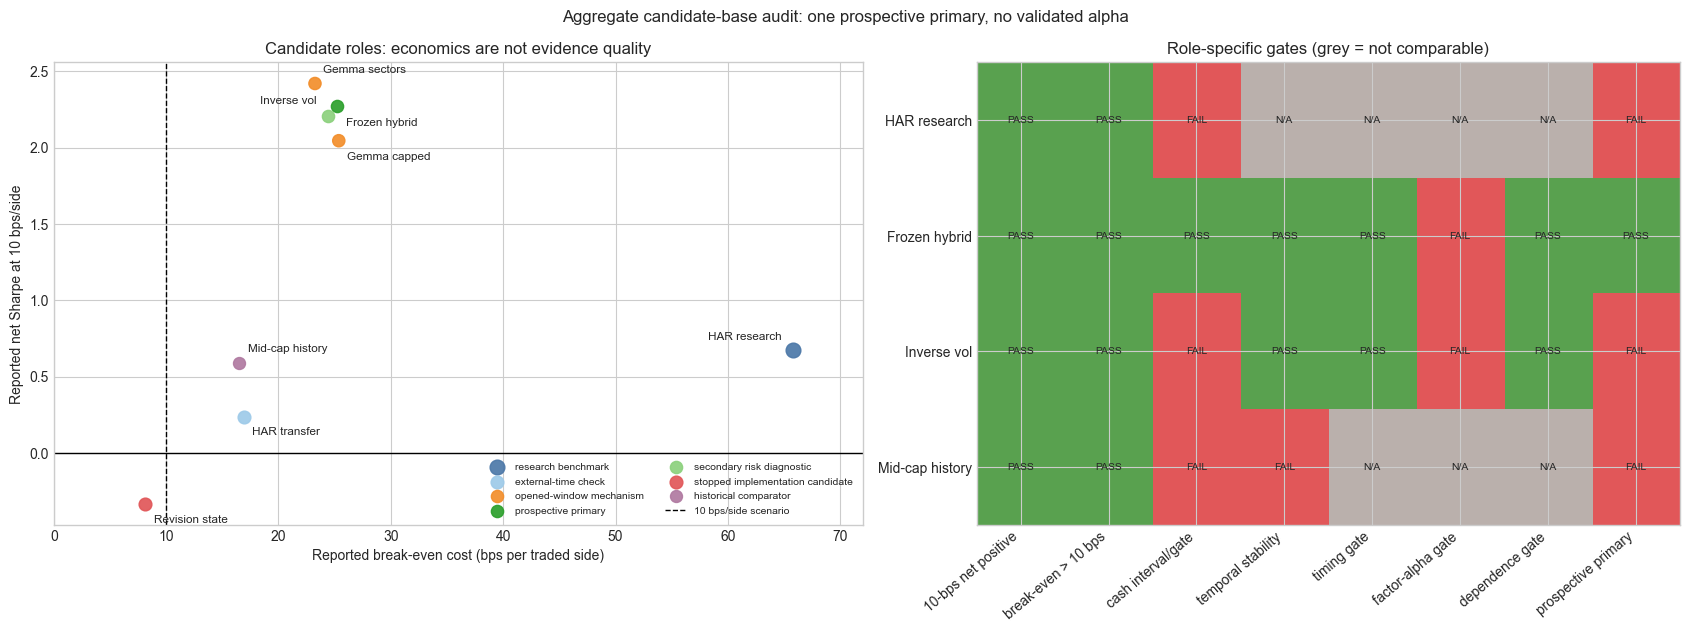

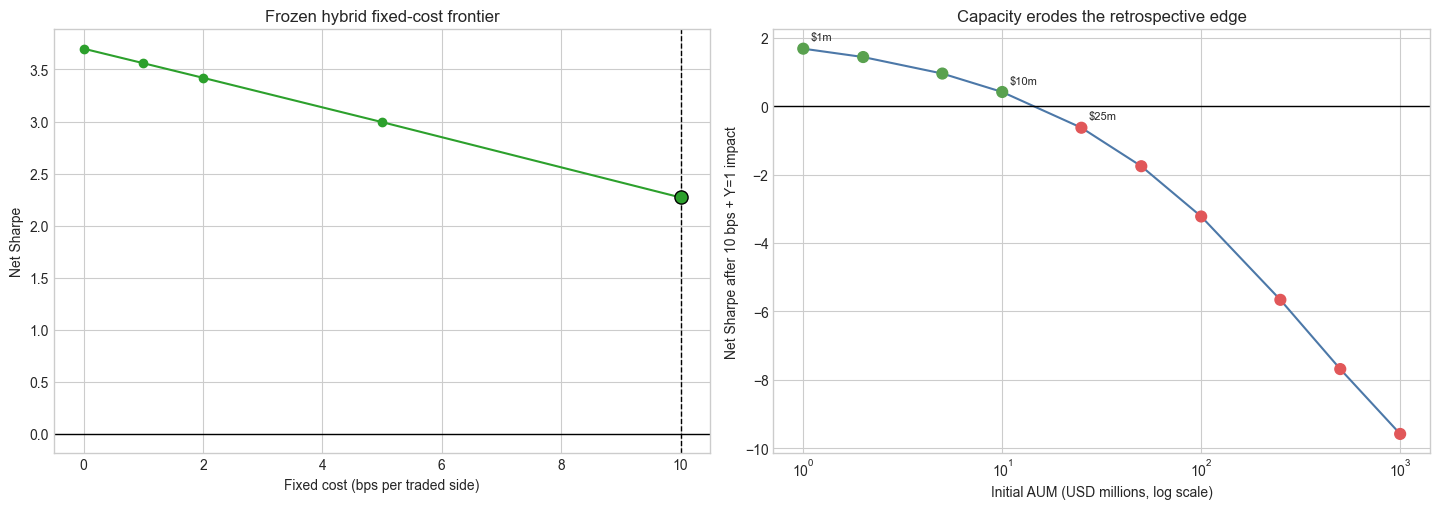

### Decision

- **A decent retrospective candidate exists:** the frozen Gemma-timing/FinBERT-ranking hybrid has gross Sharpe **3.700**, net Sharpe **2.271** at 10 bps/side, and break-even **25.24 bps/side**. At 5 bps/side its scenario net Sharpe is **2.995**.
- **The effect is not only one half:** net Sharpe is **3.364** then **0.972**, and the cash interval is **[+0.41, +13.37] bps/session**.
- **But it is not validated alpha:** sector-factor alpha is **+4.82 bps/session** with interval **[-0.44, +10.08]**, and the candidate was selected on the opened window.
- **Capacity is the practical constraint:** under the frozen Y=1 scenario, net Sharpe is **1.679** at $1m and **0.413** at $10m, but **-0.632** at $25m with **10** orders above 5% ADV.
- **Base decision:** retain HAR as the research benchmark; carry the equal-weight hybrid unchanged as the sole prospective primary; keep inverse-volatility as a non-promoting risk diagnostic and the mid-cap FinBERT rule as historical context.
- **Stop:** the prospective population is still **27/120** calendar sessions. The earliest possible required session is **2026-12-16**; no scoring or return replay is opened.

{
  "research_benchmark": "Notebook 21 sentiment-free HAR target",
  "prospective_primary": "Notebook 36 equal-weight Gemma-timing/FinBERT-ranking hybrid",
  "secondary_risk_diagnostic": "Notebook 50 inverse-volatility hybrid; not promotion eligible",
  "historical_comparator": "Notebook 55 sparse mid-cap FinBERT event rule",
  "selection_basis": "source-controlled prospective contract frozen before Notebook 57; no outcome-based reselection",
  "primary_gross_sharpe": 3.699939820207343,
  "primary_net_sharpe_at_10bps": 2.2712085876950976,
  "primary_net_sharpe_at_5bps": 2.9945606314071567,
  "primary_break_even_bps_per_side": 25.23503308593499,
  "primary_first_half_net_sharpe": 3.3639727673,
  "primary_second_half_net_sharpe": 0.9715106732,
  "primary_cash_ci_low_bps_session": 0.4144898420186822,
  "primary_cash_ci_high_bps_session": 13.3707930147026,
  "primary_sector_factor_alpha_bps_session": 4.823244600618864,
  "primary_sector_factor_ci_low_bps_session": -0.4364834311865607,
  "p

In [3]:
role_palette = {
    "research benchmark": "#4c78a8",
    "external-time check": "#9ecae9",
    "opened-window mechanism": "#f28e2b",
    "prospective primary": "#2ca02c",
    "secondary risk diagnostic": "#8cd17d",
    "stopped implementation candidate": "#e15759",
    "historical comparator": "#b07aa1",
}
annotation_offsets = {
    "HAR research": (-8, 8),
    "HAR transfer": (6, -13),
    "Gemma capped": (6, -14),
    "Gemma sectors": (6, 8),
    "Frozen hybrid": (6, -14),
    "Inverse vol": (-8, 9),
    "Revision state": (6, -14),
    "Mid-cap history": (6, 8),
}

fig, axes = plt.subplots(1, 2, figsize=(17, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})
for role, group in candidate_scorecard.groupby("role", sort=False):
    axes[0].scatter(
        group["breakeven_bps_per_side"],
        group["net_sharpe"],
        s=65 + 1.5 * np.sqrt(group["active_sessions"]),
        color=role_palette[role],
        label=role,
        alpha=0.92,
    )
for _, row in candidate_scorecard.iterrows():
    offset = annotation_offsets[row["short_label"]]
    axes[0].annotate(
        row["short_label"],
        (row["breakeven_bps_per_side"], row["net_sharpe"]),
        xytext=offset,
        textcoords="offset points",
        ha="right" if offset[0] < 0 else "left",
        fontsize=8.5,
    )
axes[0].axvline(10, color="black", ls="--", lw=1, label="10 bps/side scenario")
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel("Reported break-even cost (bps per traded side)")
axes[0].set_ylabel("Reported net Sharpe at 10 bps/side")
axes[0].set_title("Candidate roles: economics are not evidence quality")
axes[0].set_xlim(0, 72)
axes[0].legend(fontsize=7.5, loc="lower right", ncol=2)

matrix_values = gate_matrix.to_numpy(dtype=float)
matrix_display = np.where(np.isnan(matrix_values), 1, np.where(matrix_values == 1, 2, 0))
axes[1].imshow(
    matrix_display,
    aspect="auto",
    cmap=ListedColormap(["#e15759", "#bab0ac", "#59a14f"]),
    vmin=0,
    vmax=2,
)
axes[1].set_xticks(range(gate_matrix.shape[1]), gate_matrix.columns, rotation=40, ha="right")
axes[1].set_yticks(range(gate_matrix.shape[0]), gate_matrix.index)
axes[1].set_title("Role-specific gates (grey = not comparable)")
for row_index in range(gate_matrix.shape[0]):
    for column_index in range(gate_matrix.shape[1]):
        raw_value = matrix_values[row_index, column_index]
        label = "N/A" if np.isnan(raw_value) else ("PASS" if raw_value == 1 else "FAIL")
        axes[1].text(column_index, row_index, label, ha="center", va="center", fontsize=7.5)
fig.suptitle("Aggregate candidate-base audit: one prospective primary, no validated alpha")
fig.tight_layout()
fig.savefig(OUTPUT / "candidate_base_scorecard.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.2))
axes[0].plot(
    cost_frontier["cost_bps_per_side"],
    cost_frontier["sharpe_net"],
    marker="o",
    color="#2ca02c",
)
axes[0].axhline(0, color="black", lw=1)
axes[0].axvline(10, color="black", ls="--", lw=1)
axes[0].scatter([10], [cost_10["sharpe_net"]], s=90, color="#2ca02c", edgecolor="black", zorder=3)
axes[0].set_xlabel("Fixed cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Frozen hybrid fixed-cost frontier")

capacity_colours = np.where(
    capacity_frontier["capacity_gate_at_grid_point"], "#59a14f", "#e15759"
)
axes[1].plot(
    capacity_frontier["initial_aum_usd"] / 1_000_000,
    capacity_frontier["sharpe_net"],
    color="#4c78a8",
    lw=1.5,
)
axes[1].scatter(
    capacity_frontier["initial_aum_usd"] / 1_000_000,
    capacity_frontier["sharpe_net"],
    c=capacity_colours,
    s=60,
    zorder=3,
)
for row in [capacity_1m, capacity_10m, capacity_25m]:
    axes[1].annotate(
        f"${row['initial_aum_usd'] / 1_000_000:.0f}m",
        (row["initial_aum_usd"] / 1_000_000, row["sharpe_net"]),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8,
    )
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("Initial AUM (USD millions, log scale)")
axes[1].set_ylabel("Net Sharpe after 10 bps + Y=1 impact")
axes[1].set_title("Capacity erodes the retrospective edge")
fig.tight_layout()
fig.savefig(OUTPUT / "hybrid_cost_and_capacity_frontier.png", dpi=180, bbox_inches="tight")
plt.show()

manifest = {
    "notebook": "57_aggregate_candidate_base_frontier.ipynb",
    "status": "complete_aggregate_only_candidate_base_audit_no_new_returns",
    "seed": SEED,
    "git_commit_at_execution": git_commit(),
    "input_boundary": {
        "aggregate_csv_files": CSV_PATHS,
        "aggregate_json_files": JSON_PATHS,
        "source_sha256": dict(zip(source_files["path"], source_files["sha256"])),
        "row_level_returns_loaded": False,
        "prices_loaded": False,
        "positions_loaded": False,
        "scores_loaded": False,
        "headline_text_loaded": False,
        "licensed_text_emitted": False,
        "new_signal_constructed": False,
        "new_return_constructed": False,
    },
    "counts": {
        "source_files": int(len(source_files)),
        "candidate_rows": int(len(candidate_scorecard)),
        "gate_rows": int(len(gate_matrix)),
        "fixed_cost_points": int(len(cost_frontier)),
        "capacity_points_y1": int(len(capacity_frontier)),
    },
    "policy": {
        "cross_regime_metrics_pooled": False,
        "candidate_reselected_from_notebook_57_outcomes": False,
        "prospective_contract_changed": False,
        "historical_tuning_reopened": False,
    },
    "decision": decision,
    "limitations": [
        "Reported Sharpes span different universes, dates, accounting conventions, and selection histories and are not directly ranked.",
        "The Notebook 36 candidate was selected through an iterative opened-window chain; Notebook 57 adds no independent return evidence.",
        "The fixed-cost curve is a scenario, not proof of achievable execution cost.",
        "The square-root impact curve uses lagged full-day ADV and assumed Y=1; opening-auction capacity may be lower.",
        "Borrow, financing, taxes, short-sale constraints, and order-book depth are not modelled.",
        "The sector-factor alpha interval crosses zero and the prospective population remains below its frozen minimum.",
        "Human validation of full-corpus Gemma sentiment remains open.",
    ],
}
(OUTPUT / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")

display(Markdown(
    "### Decision\n\n"
    "- **A decent retrospective candidate exists:** the frozen Gemma-timing/FinBERT-ranking hybrid has "
    f"gross Sharpe **{decision['primary_gross_sharpe']:.3f}**, net Sharpe **{decision['primary_net_sharpe_at_10bps']:.3f}** "
    f"at 10 bps/side, and break-even **{decision['primary_break_even_bps_per_side']:.2f} bps/side**. "
    f"At 5 bps/side its scenario net Sharpe is **{decision['primary_net_sharpe_at_5bps']:.3f}**.\n"
    f"- **The effect is not only one half:** net Sharpe is **{decision['primary_first_half_net_sharpe']:.3f}** then "
    f"**{decision['primary_second_half_net_sharpe']:.3f}**, and the cash interval is "
    f"**[{decision['primary_cash_ci_low_bps_session']:+.2f}, {decision['primary_cash_ci_high_bps_session']:+.2f}] bps/session**.\n"
    f"- **But it is not validated alpha:** sector-factor alpha is **{decision['primary_sector_factor_alpha_bps_session']:+.2f} bps/session** "
    f"with interval **[{decision['primary_sector_factor_ci_low_bps_session']:+.2f}, "
    f"{decision['primary_sector_factor_ci_high_bps_session']:+.2f}]**, and the candidate was selected on the opened window.\n"
    f"- **Capacity is the practical constraint:** under the frozen Y=1 scenario, net Sharpe is "
    f"**{decision['impact_y1_net_sharpe_1m']:.3f}** at $1m and **{decision['impact_y1_net_sharpe_10m']:.3f}** at $10m, "
    f"but **{decision['impact_y1_net_sharpe_25m']:.3f}** at $25m with "
    f"**{decision['impact_y1_25m_orders_over_5pct_adv']}** orders above 5% ADV.\n"
    "- **Base decision:** retain HAR as the research benchmark; carry the equal-weight hybrid unchanged as the sole prospective primary; "
    "keep inverse-volatility as a non-promoting risk diagnostic and the mid-cap FinBERT rule as historical context.\n"
    f"- **Stop:** the prospective population is still **{decision['prospective_calendar_sessions_observed_or_upper_bound']}/"
    f"{decision['prospective_calendar_sessions_required']}** calendar sessions. The earliest possible required session is "
    f"**{decision['prospective_earliest_possible_required_session']}**; no scoring or return replay is opened."
))
print(json.dumps(decision, indent=2))


## Next steps

1. Do not tune the hybrid, inverse-volatility weights, event threshold, holding
   period, or cost assumption on the opened window.
2. Continue the immutable post-2026-06-26 LSEG headline ledger. Only after the
   120-session, 60-active-session, and 20-per-half population gates pass should
   the fixed Gemma and FinBERT scorers run and the primary replay open once.
3. Treat 10 bps plus Y=1 impact as the main implementation scenario; report 1m,
   10m, and 25m results rather than claiming a single capacity number.
4. Promotion still requires the prospective cash, both-halves, factor-alpha,
   dependence, Gate F1, and human-label conditions.
